In [1]:
!nvidia-smi
import os
HOME = os.getcwd()
print(HOME)

Fri Nov  7 17:38:57 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!pip install ultralytics roboflow -q
import ultralytics
ultralytics.checks()

Ultralytics 8.3.226 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 39.5/112.6 GB disk)


In [3]:
!mkdir -p {HOME}/datasets
%cd {HOME}/datasets

/content/datasets


In [4]:
from roboflow import Roboflow
rf = Roboflow(api_key="ys8HpBLUxOd3R4iYGsuB")
project = rf.workspace("ntut-zy5y0").project("weapon-detection-yfvuq")
version = project.version(3)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Weapon-detection-3 in yolov8:: 100%|██████████| 6012/6012 [00:00<00:00, 6196.19it/s]


In [5]:
!ls {dataset.location}
print("\n" + "="*50)
!cat {dataset.location}/data.yaml

data.yaml  README.dataset.txt  README.roboflow.txt  test  train  valid

names:
- baseball-bat
- knife
- pistol
nc: 3
roboflow:
  license: CC BY 4.0
  project: weapon-detection-yfvuq
  url: https://universe.roboflow.com/ntut-zy5y0/weapon-detection-yfvuq/dataset/3
  version: 3
  workspace: ntut-zy5y0
test: ../test/images
train: ../train/images
val: ../valid/images


In [6]:
%cd {HOME}
!yolo task=detect mode=train model=yolov8n.pt data={dataset.location}/data.yaml epochs=100 imgsz=640 batch=16 plots=True patience=50 save=True device=0 project=runs/detect name=weapon_detection

/content
Ultralytics 8.3.226 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/datasets/Weapon-detection-3/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=weapon_detection, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=50, 

In [7]:
!ls /content/runs/detect/weapon_detection

args.yaml			 results.csv	       val_batch0_labels.jpg
BoxF1_curve.png			 results.png	       val_batch0_pred.jpg
BoxP_curve.png			 train_batch0.jpg      val_batch1_labels.jpg
BoxPR_curve.png			 train_batch11880.jpg  val_batch1_pred.jpg
BoxR_curve.png			 train_batch11881.jpg  val_batch2_labels.jpg
confusion_matrix_normalized.png  train_batch11882.jpg  val_batch2_pred.jpg
confusion_matrix.png		 train_batch1.jpg      weights
labels.jpg			 train_batch2.jpg


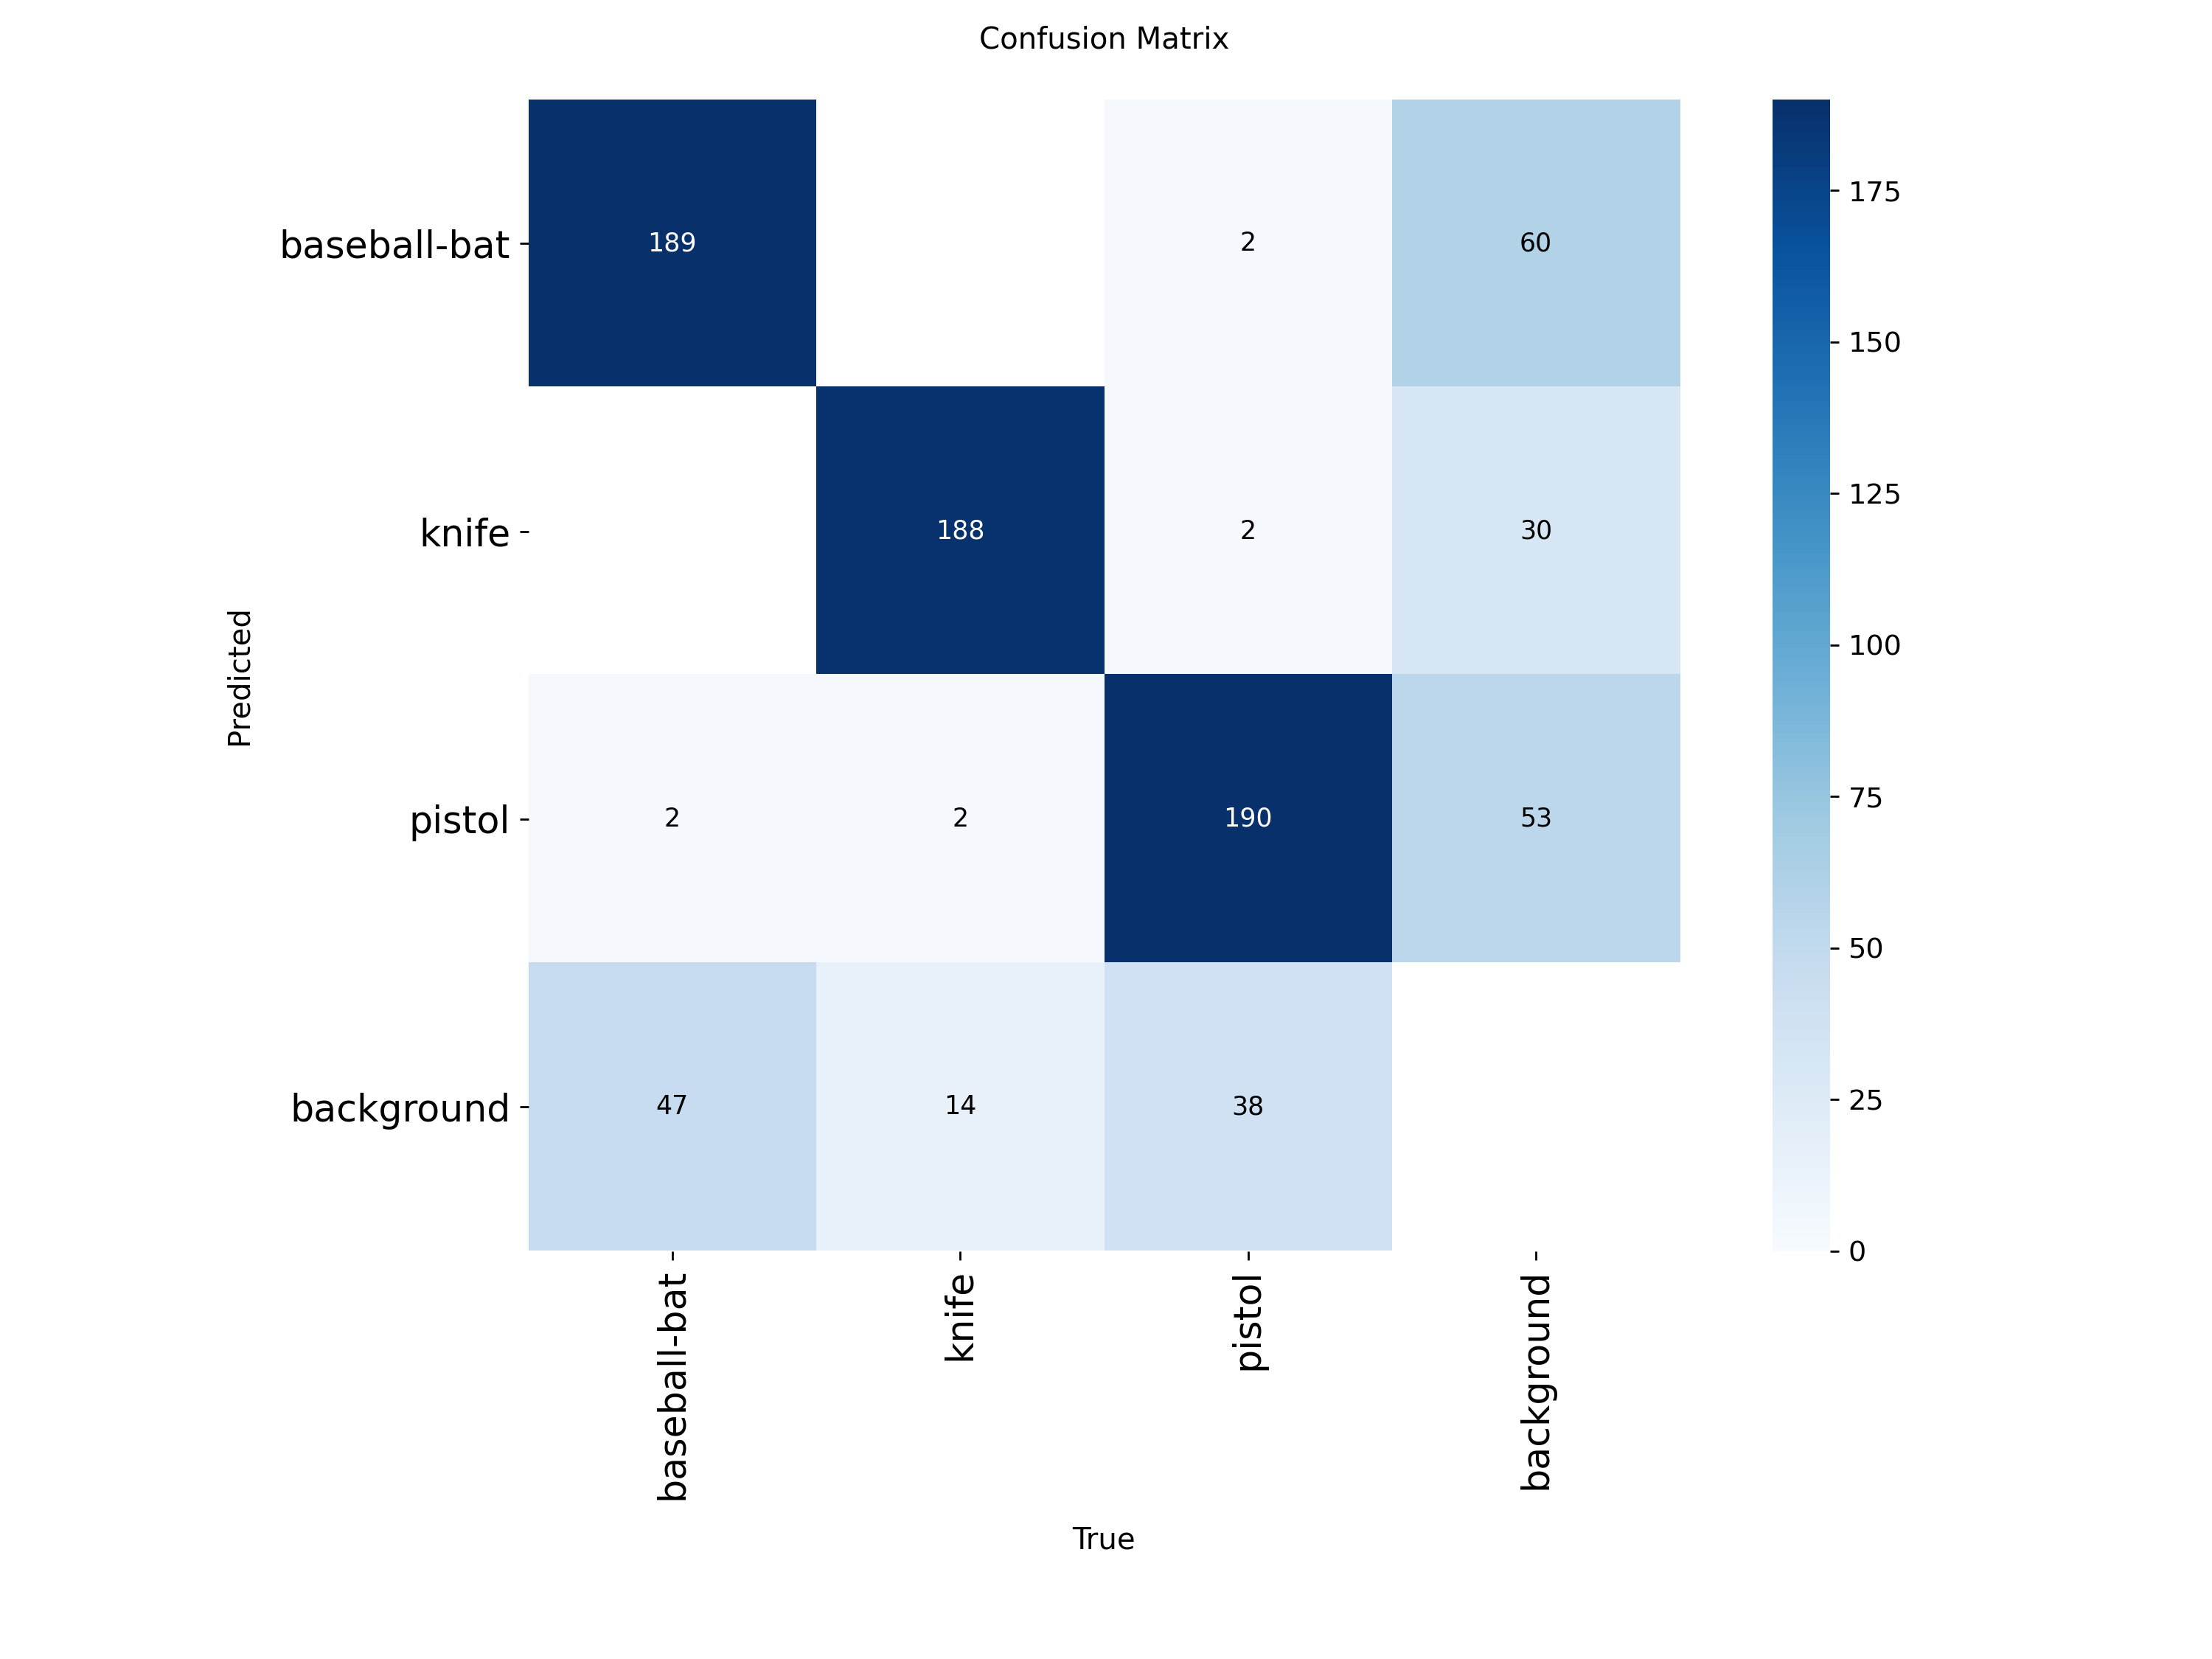

In [8]:
from IPython.display import Image, display
display(Image(filename='/content/runs/detect/weapon_detection/confusion_matrix.png'))

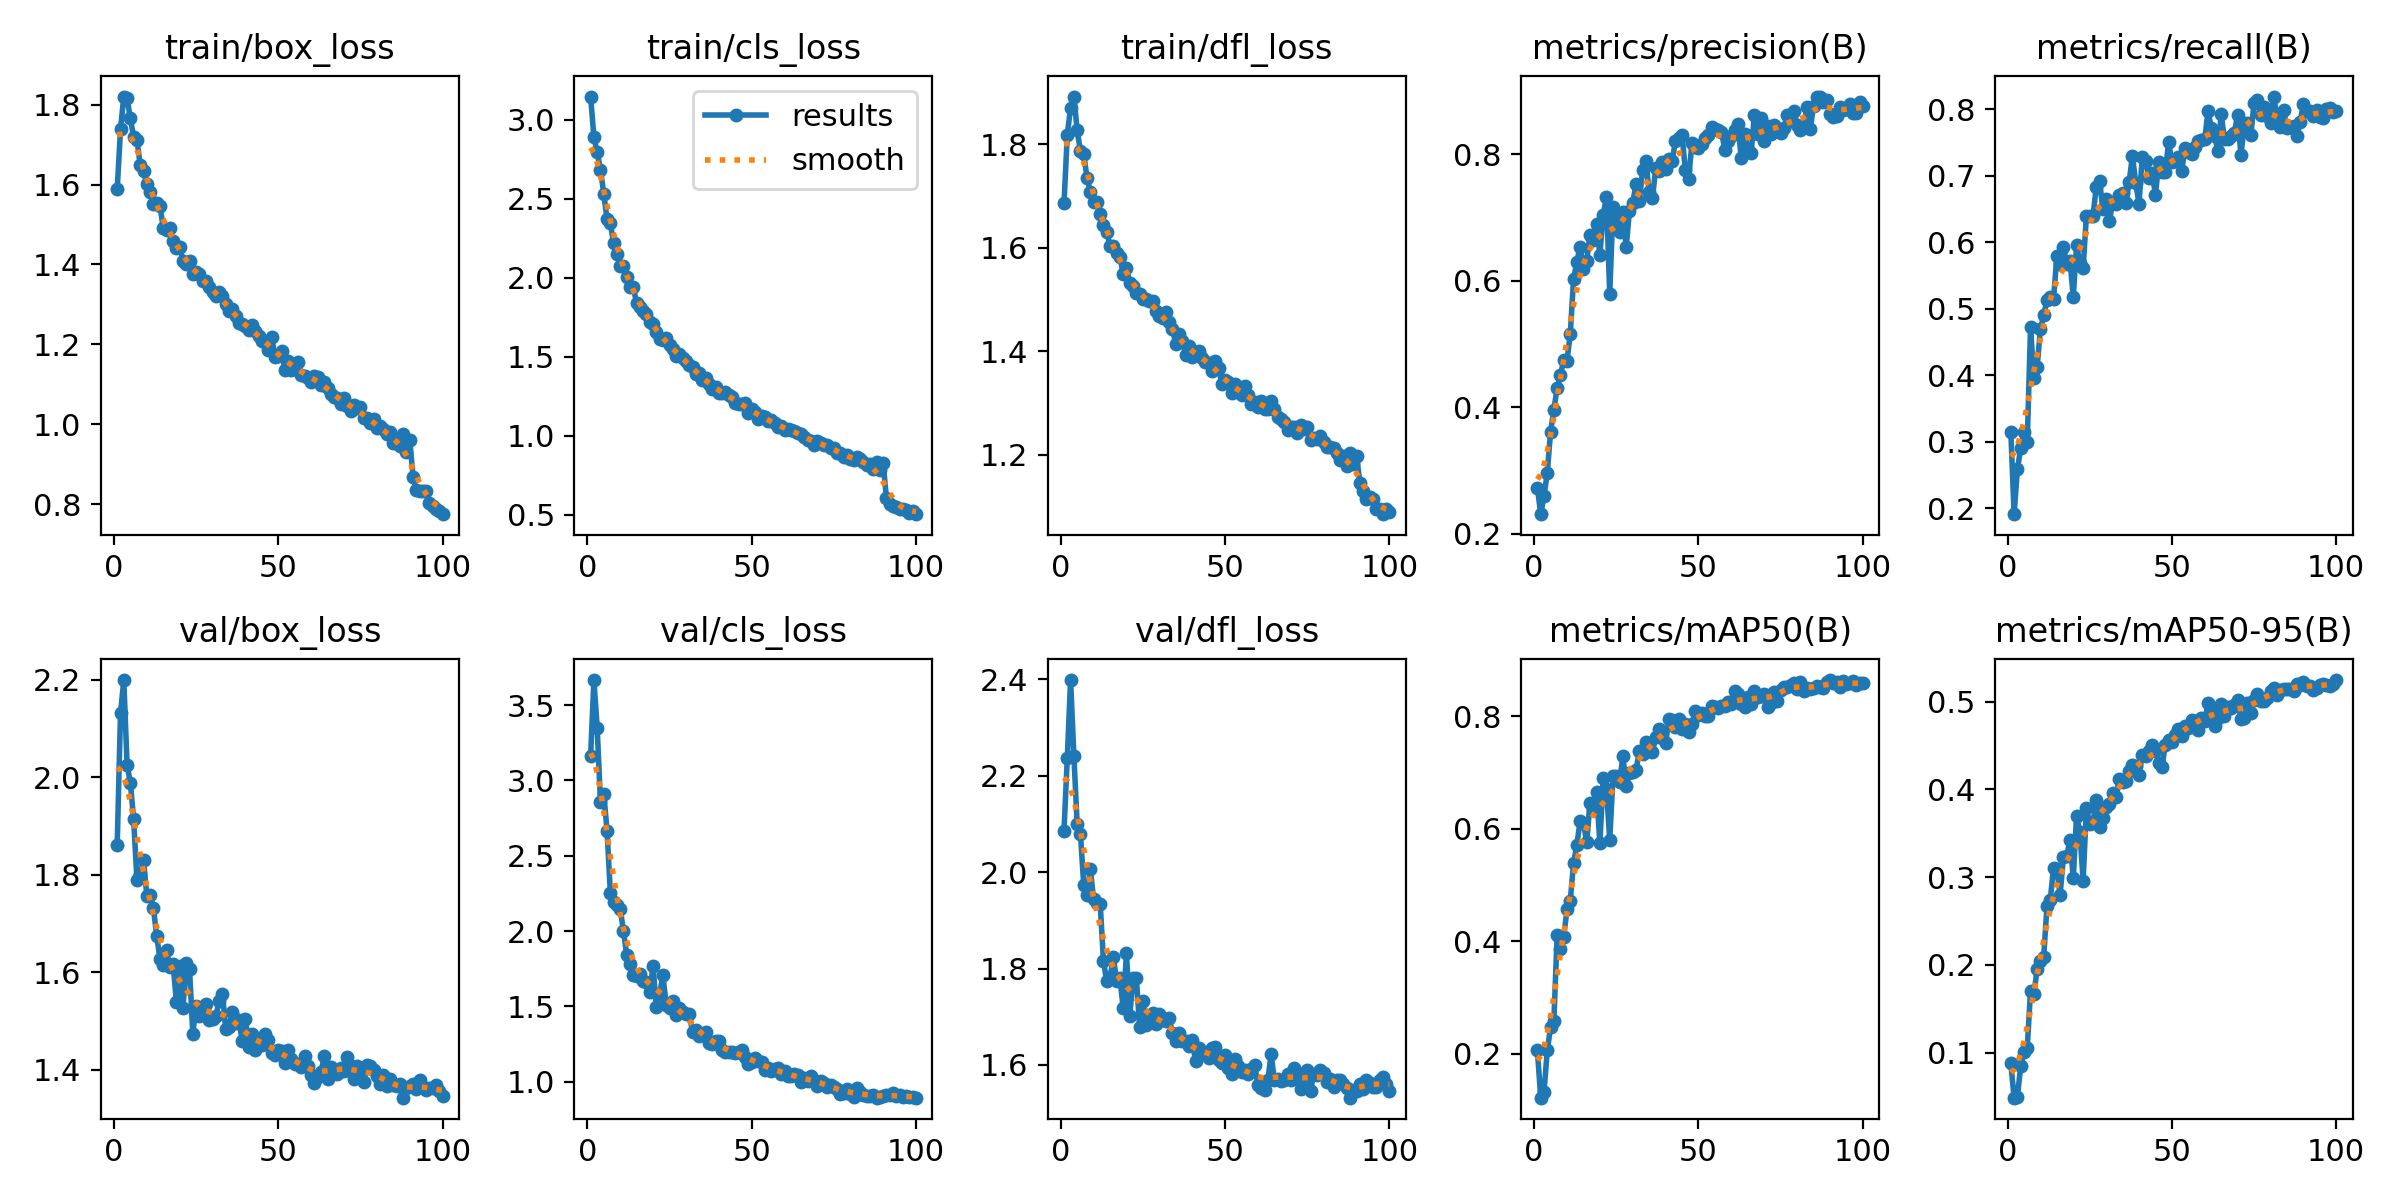

In [9]:
display(Image(filename='/content/runs/detect/weapon_detection/results.png'))

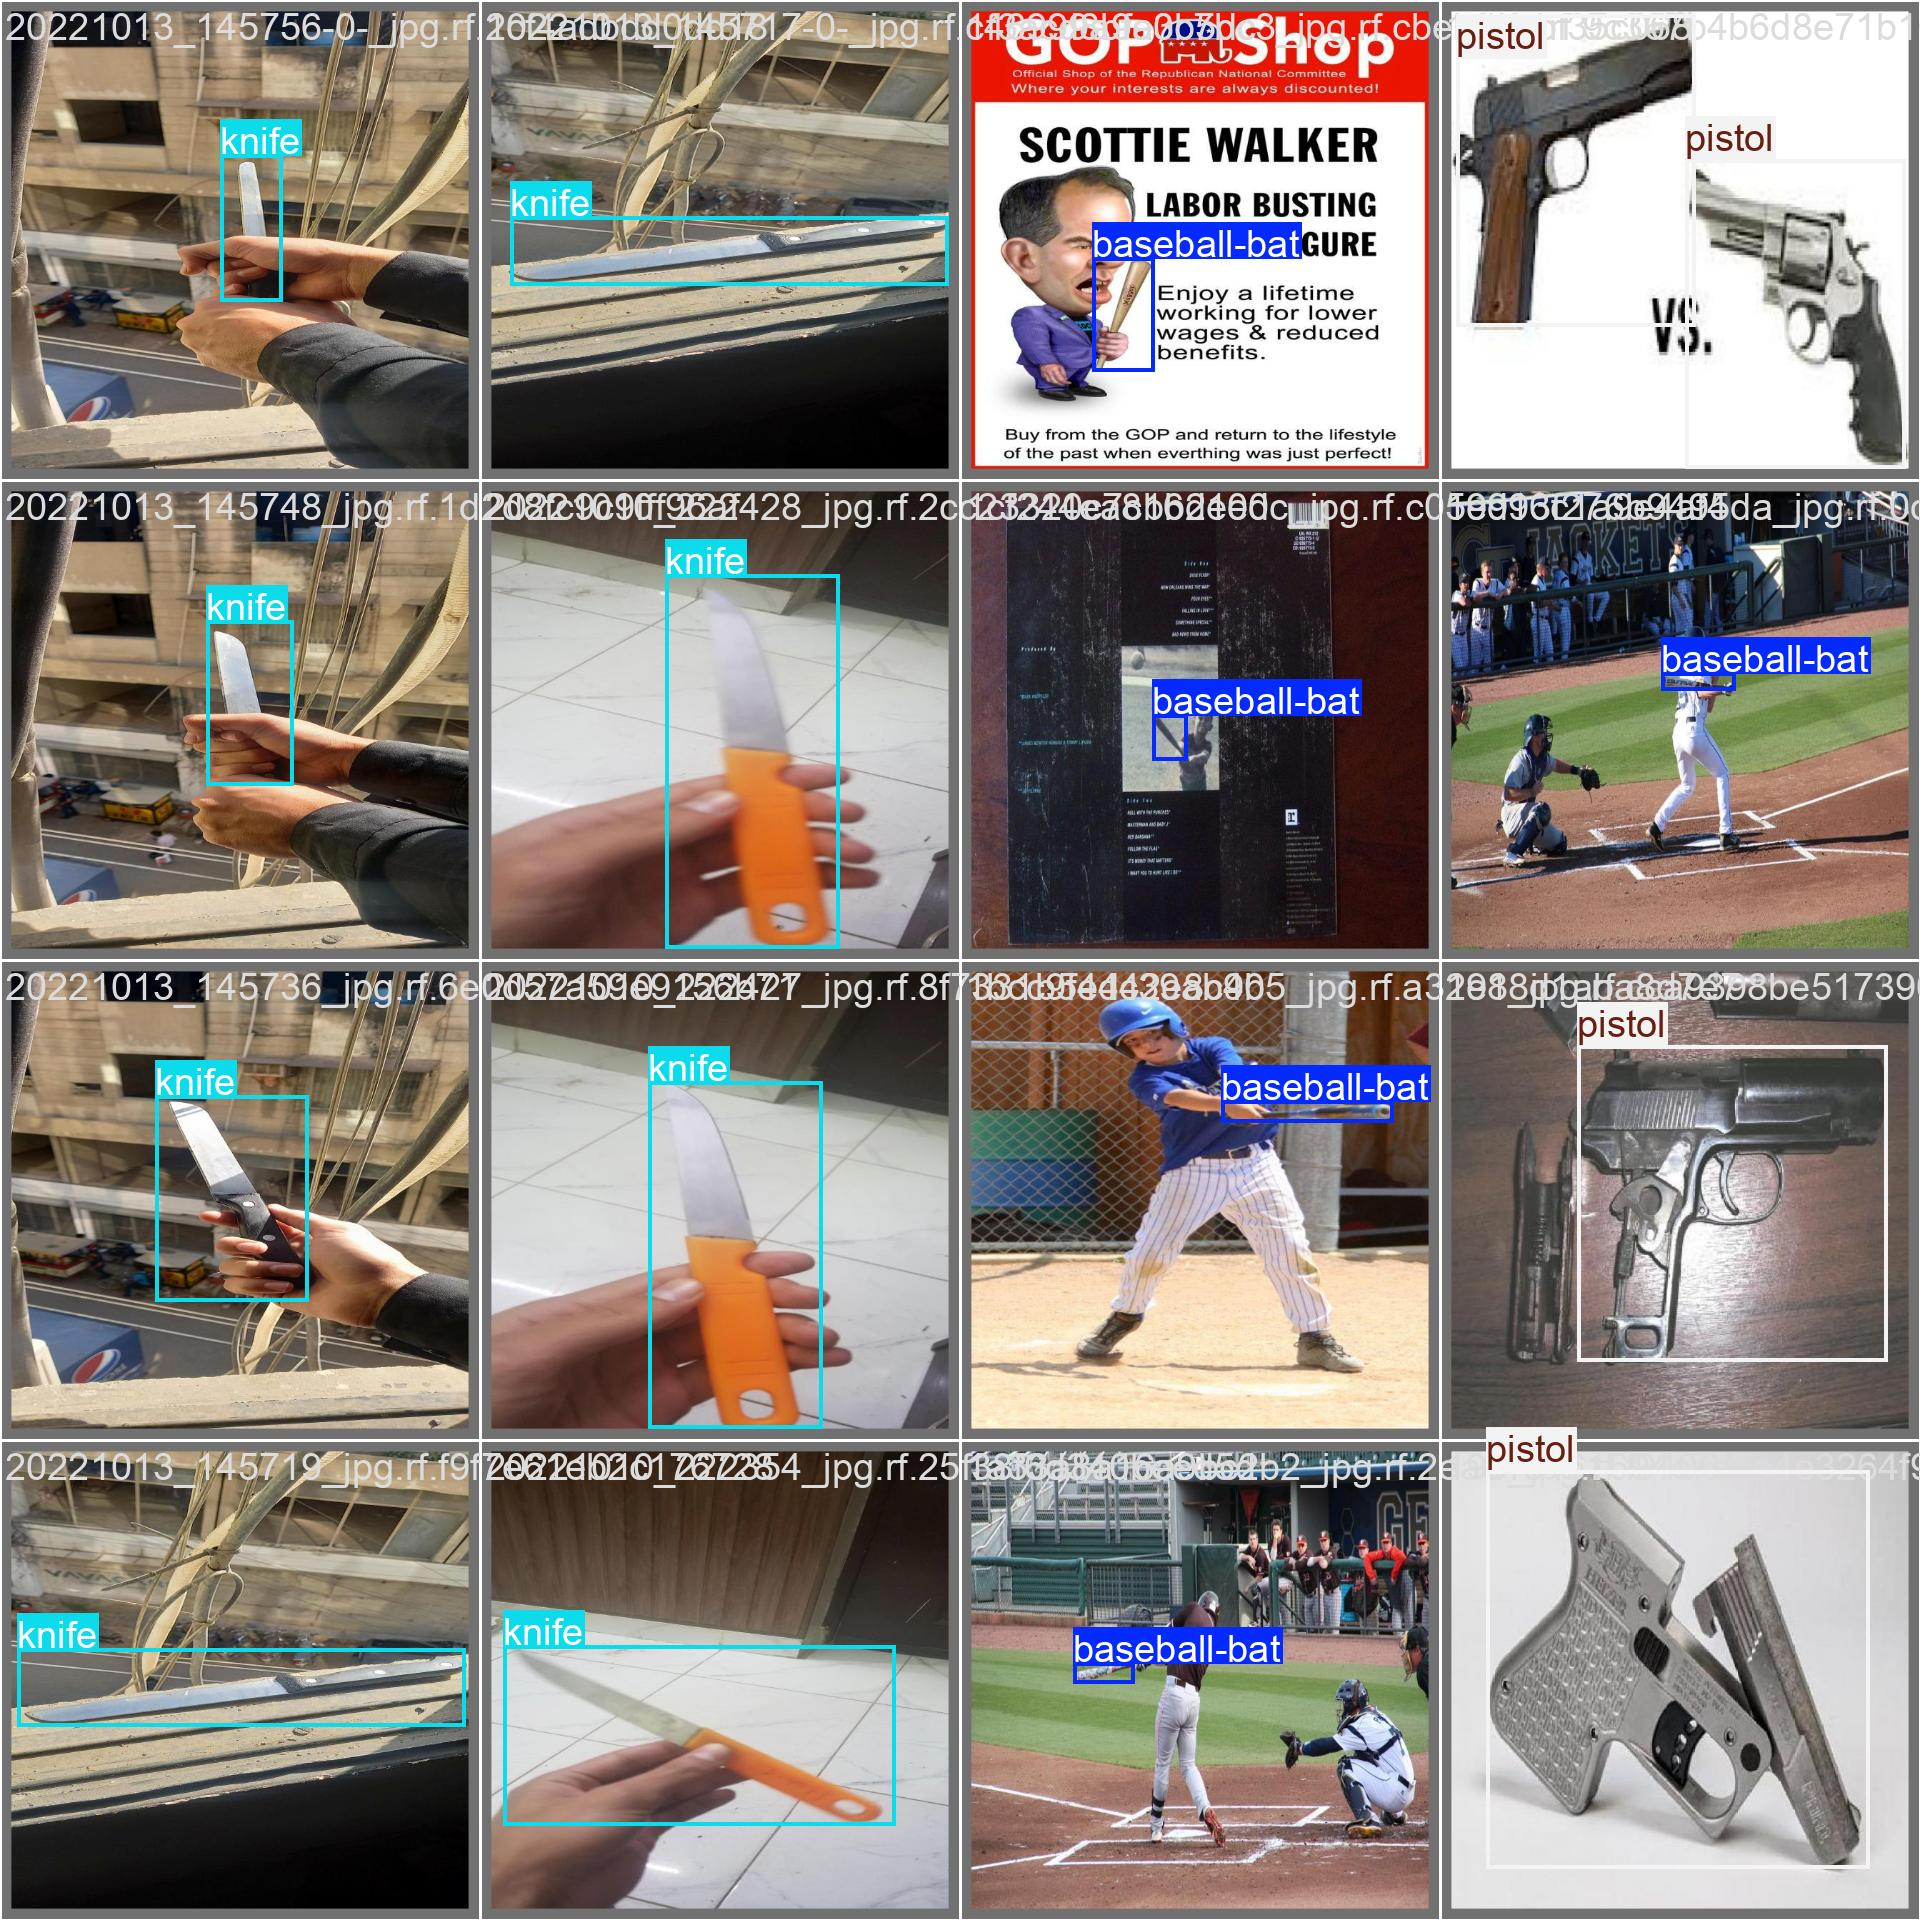

In [12]:
display(Image(filename='/content/runs/detect/weapon_detection/val_batch2_labels.jpg'))

In [13]:
!yolo task=detect mode=val model=/content/runs/detect/weapon_detection/weights/best.pt data={dataset.location}/data.yaml

Ultralytics 8.3.226 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1291.9±319.9 MB/s, size: 46.6 KB)
val: Scanning /content/datasets/Weapon-detection-3/valid/labels.cache... 600 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 600/600 7.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 38/38 6.3it/s 6.1s
                   all        600        674      0.876      0.798      0.859      0.524
          baseball-bat        205        238      0.856      0.727      0.797       0.44
                 knife        200        204      0.907      0.904      0.926      0.585
                pistol        195        232      0.865      0.763      0.853      0.549
Speed: 1.4ms preprocess, 3.8ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to /content/runs/detect

In [14]:
!yolo task=detect mode=predict model=/content/runs/detect/weapon_detection/weights/best.pt source={dataset.location}/test/images conf=0.25 save=True

Ultralytics 8.3.226 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs

image 1/300 /content/datasets/Weapon-detection-3/test/images/000005_jpg.rf.f1529d7c1a7546238a23374a8b002ba8.jpg: 640x640 1 baseball-bat, 9.0ms
image 2/300 /content/datasets/Weapon-detection-3/test/images/000009_jpg.rf.77c0e0070a4fed0c28c176e16383b1ba.jpg: 640x640 1 baseball-bat, 8.8ms
image 3/300 /content/datasets/Weapon-detection-3/test/images/000013_jpg.rf.43a56712aff1a4be8590313d6456dd07.jpg: 640x640 1 baseball-bat, 7.3ms
image 4/300 /content/datasets/Weapon-detection-3/test/images/000014_jpg.rf.f848f03c14190eb35866db18aa5b2c5c.jpg: 640x640 3 baseball-bats, 7.2ms
image 5/300 /content/datasets/Weapon-detection-3/test/images/000027_jpg.rf.72e31688ec5771672e62bda754976d45.jpg: 640x640 2 baseball-bats, 7.2ms
image 6/300 /content/datasets/Weapon-detection-3/test/images/000028_jpg.rf.c4b366cc8cdc0bbc260820b40b407ecd.jpg: 640x64

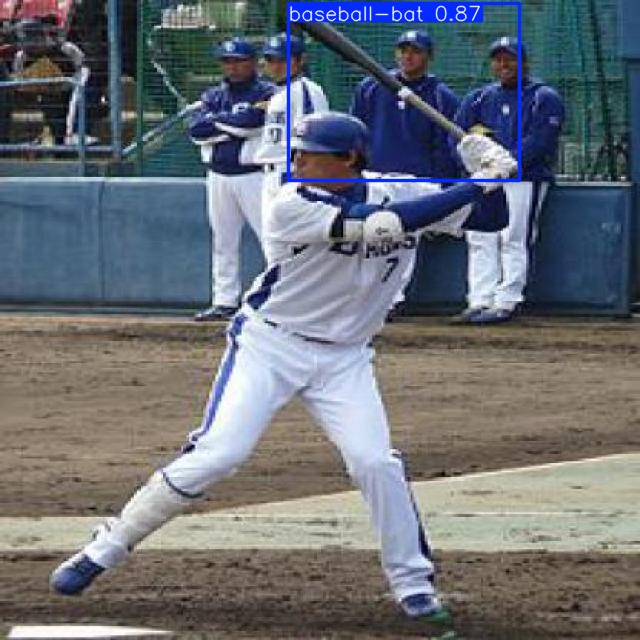

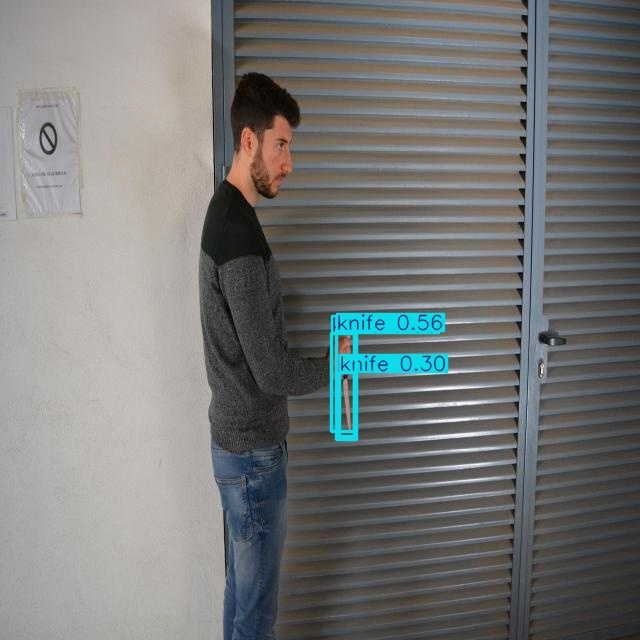

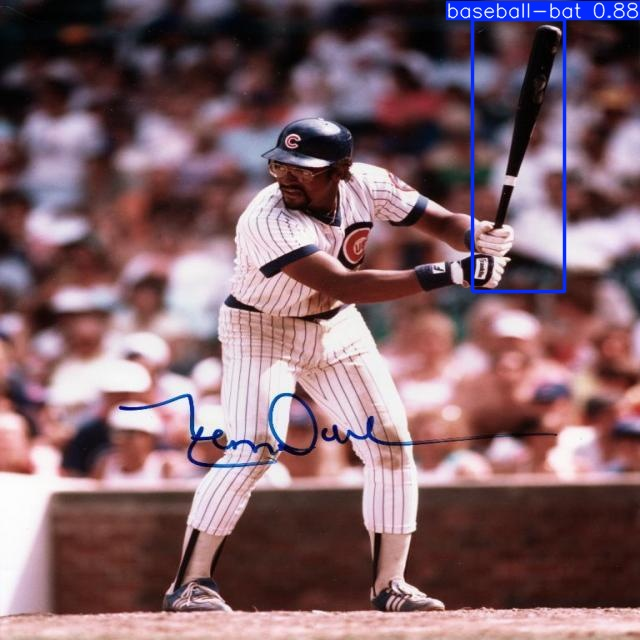

In [15]:
import glob
latest_folder = max(glob.glob('/content/runs/detect/predict*/'), key=os.path.getmtime)
for img in glob.glob(f'{latest_folder}*.jpg')[:3]:
    display(Image(filename=img, width=600))
    print("\n")

In [17]:
from google.colab import files
files.download('/content/runs/detect/weapon_detection/weights/best.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

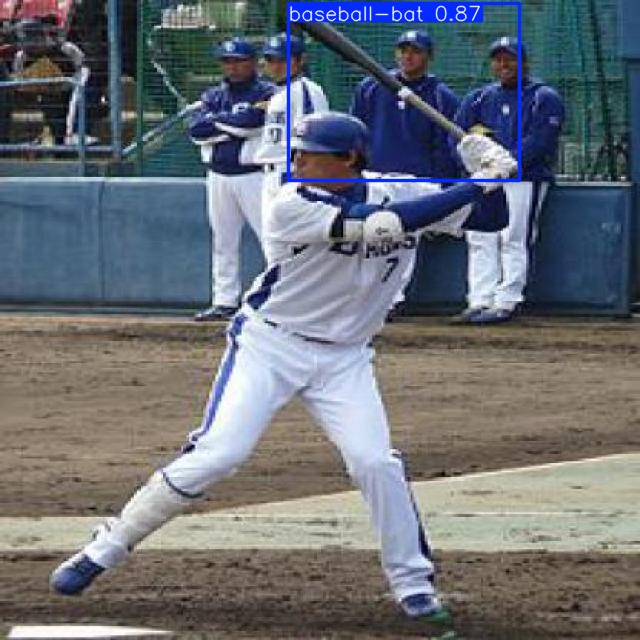

In [18]:
from IPython.display import Image, display
import glob
sample = glob.glob('/content/runs/detect/predict/*.jpg')[0]
display(Image(filename=sample, width=600))

In [21]:
!zip -r /content/weapon_detection_complete.zip /content/runs /content/datasets /content/*.pt
from google.colab import files
files.download('/content/weapon_detection_complete.zip')

Streaming output truncated to the last 5000 lines.
  adding: content/datasets/Weapon-detection-3/valid/images/20221013_212135_jpg.rf.e7e41913cb119d282af8212413074603.jpg (deflated 2%)
  adding: content/datasets/Weapon-detection-3/valid/images/496_jpg.rf.6b85bf619f2f1a6da3886452b2f6c5af.jpg (deflated 3%)
  adding: content/datasets/Weapon-detection-3/valid/images/knife_126_jpg.rf.a64530d509a0aa938814b6566840a5b2.jpg (deflated 16%)
  adding: content/datasets/Weapon-detection-3/valid/images/e03693495c7b54ff_jpg.rf.a79c51fa522c76949e58769d13ca3b28.jpg (deflated 1%)
  adding: content/datasets/Weapon-detection-3/valid/images/fba2fca6fd5a6a9e_jpg.rf.bdd4b7cb8b6dafb10a924c4e1f21058c.jpg (deflated 0%)
  adding: content/datasets/Weapon-detection-3/valid/images/bb3748ddd4964bd4_jpg.rf.da3e16998e66569b84c2a5cc08cb39da.jpg (deflated 0%)
  adding: content/datasets/Weapon-detection-3/valid/images/478837215-1621406735_jpeg_jpg.rf.a13b0239f28883cdc5f096d3502e881e.jpg (deflated 1%)
  adding: content/data

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>